--- Tasks 1 & 2: Iris Decision Tree ---


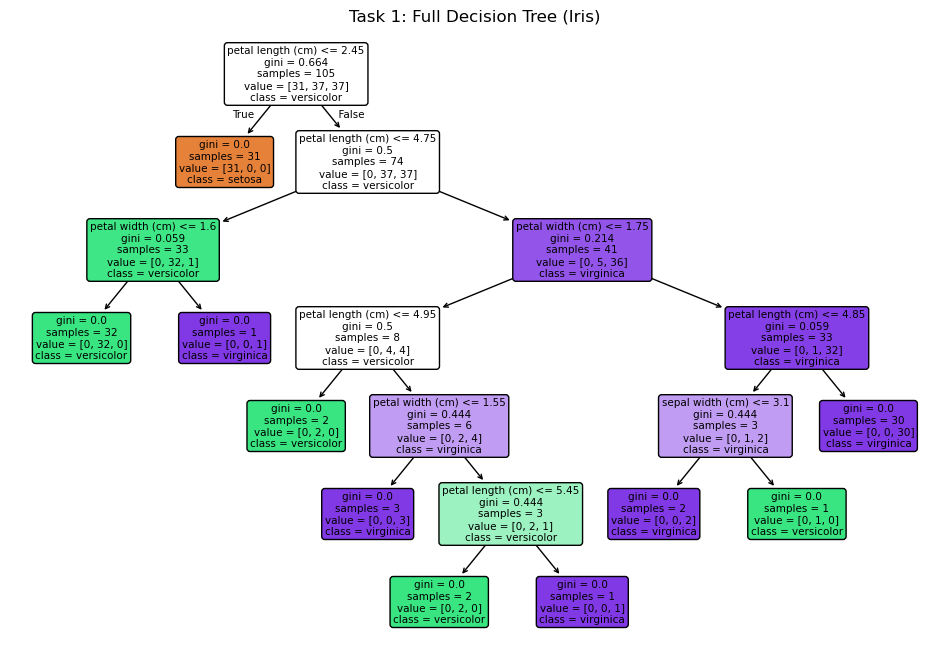

Max Depth: 1 | Train Acc: 0.648 | Test Acc: 0.711
Max Depth: 2 | Train Acc: 0.943 | Test Acc: 0.978
Max Depth: 3 | Train Acc: 0.952 | Test Acc: 1.000
Max Depth: 4 | Train Acc: 0.971 | Test Acc: 1.000
Max Depth: None | Train Acc: 1.000 | Test Acc: 1.000


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ==========================================
# TASKS 1 & 2: Decision Tree on Iris Dataset
# ==========================================
print("--- Tasks 1 & 2: Iris Decision Tree ---")

# Load Iris Data
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = iris.target

# Train-Test Split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

# Task 1: Train default Decision Tree and Visualise
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_i, y_train_i)

plt.figure(figsize=(12, 8))
plot_tree(dt_default, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Task 1: Full Decision Tree (Iris)")
plt.show()

# Task 2: Tune max_depth and compare accuracy
depths = [1, 2, 3, 4, None] # None means fully grown tree
for depth in depths:
    dt_tuned = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_tuned.fit(X_train_i, y_train_i)
    
    # Predict and calculate accuracy
    train_acc = accuracy_score(y_train_i, dt_tuned.predict(X_train_i))
    test_acc = accuracy_score(y_test_i, dt_tuned.predict(X_test_i))
    
    print(f"Max Depth: {depth} | Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")
# Notice how 'None' (full depth) has 1.000 train accuracy but lower test accuracy—this is overfitting!


--- Tasks 3 & 4: Titanic Random Forest ---
Random Forest Accuracy on Titanic: 0.776


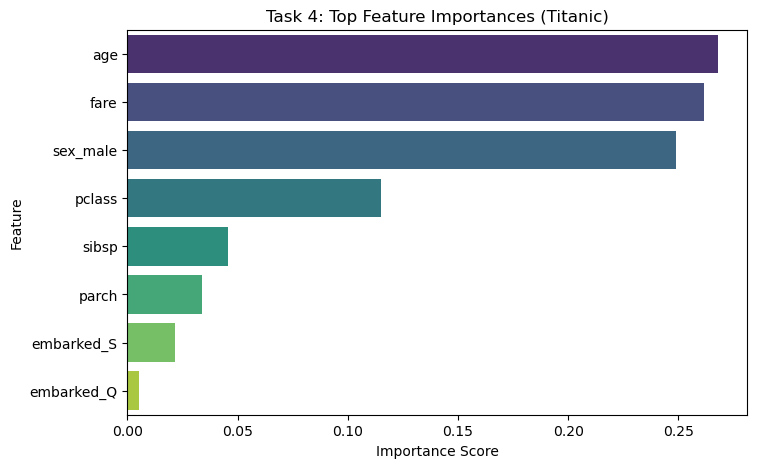

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ==========================================
# TASKS 3 & 4: Random Forest on Titanic Data
# ==========================================
print("\n--- Tasks 3 & 4: Titanic Random Forest ---")

# Load Titanic Data
titanic = sns.load_dataset('titanic')

# Quick Preprocessing (Dropping text columns, handling NAs, encoding categories)
# Keep it simple for this exercise
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
titanic_clean = titanic[features + ['survived']].dropna() # Drop rows with missing values
X_tit = pd.get_dummies(titanic_clean[features], drop_first=True) # Convert text to numbers
y_tit = titanic_clean['survived']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_tit, y_tit, test_size=0.3, random_state=42)

# Task 3: Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_t, y_train_t)

rf_acc = accuracy_score(y_test_t, rf.predict(X_test_t))
print(f"Random Forest Accuracy on Titanic: {rf_acc:.3f}")

# Task 4: Plot Top Feature Importances
importances = rf.feature_importances_
feature_names = X_train_t.columns

# Create a DataFrame for easy plotting
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False).head(10) # Get top 10

plt.figure(figsize=(8, 5))

# --- UPDATED LINE BELOW ---
sns.barplot(x='Importance', y='Feature', data=df_imp, hue='Feature', palette='viridis', legend=False)

plt.title("Task 4: Top Feature Importances (Titanic)")
plt.xlabel("Importance Score")
plt.show()

In [5]:
# ==========================================
# PRACTICE SHEET: Loan Approval Prediction
# ==========================================
print("\n--- Practice Sheet: DT vs RF on Loan Data ---")

# 1. Create a Synthetic Loan Dataset
np.random.seed(42)
n_samples = 1000

loan_data = pd.DataFrame({
    'Credit_Score': np.random.randint(300, 850, n_samples),
    'Income': np.random.randint(30000, 150000, n_samples),
    'Debt_to_Income_Ratio': np.random.uniform(0.1, 0.6, n_samples),
    'Years_at_Job': np.random.randint(0, 20, n_samples),
    'Loan_Amount': np.random.randint(5000, 50000, n_samples)
})

# Create a logical target variable (Approval) based on a few rules, with some added noise
# High credit, high income, low debt = Approved (1)
conditions = (loan_data['Credit_Score'] > 650) & (loan_data['Debt_to_Income_Ratio'] < 0.4)
# Add some randomness to make it realistic
loan_data['Approved'] = np.where(conditions, np.random.choice([1, 0], p=[0.85, 0.15], size=n_samples), 
                                             np.random.choice([1, 0], p=[0.20, 0.80], size=n_samples))

# 2. Prepare the Data
X_loan = loan_data.drop('Approved', axis=1)
y_loan = loan_data['Approved']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_loan, y_loan, test_size=0.3, random_state=42)

# 3. Train Decision Tree
dt_loan = DecisionTreeClassifier(random_state=42)
dt_loan.fit(X_train_l, y_train_l)
dt_loan_preds = dt_loan.predict(X_test_l)
dt_loan_acc = accuracy_score(y_test_l, dt_loan_preds)

# 4. Train Random Forest
rf_loan = RandomForestClassifier(n_estimators=100, random_state=42)
rf_loan.fit(X_train_l, y_train_l)
rf_loan_preds = rf_loan.predict(X_test_l)
rf_loan_acc = accuracy_score(y_test_l, rf_loan_preds)

# 5. Compare Results
print(f"Decision Tree Accuracy:  {dt_loan_acc:.3f}")
print(f"Random Forest Accuracy:  {rf_loan_acc:.3f}")




--- Practice Sheet: DT vs RF on Loan Data ---
Decision Tree Accuracy:  0.687
Random Forest Accuracy:  0.797
